# 🏆 Ejercicio Global — Tema 2: Transformaciones de Datos
## Diplomado en Machine Learning en Seguros

### Contexto
Eres actuario en una aseguradora de **autos en México**. Recibes un dataset crudo de pólizas 
y siniestros del año 2024 y debes prepararlo para un modelo predictivo de siniestralidad.

### Objetivos
1. ✅ Calcular variables derivadas actuariales (edad, exposición, antigüedad)
2. ✅ Codificar variables categóricas apropiadamente
3. ✅ Aplicar transformaciones a variables asimétricas  
4. ✅ Escalar variables numéricas
5. ✅ Hacer feature engineering con efectos calendario y segmentación de riesgo
6. ✅ Construir el dataset final listo para modelar

### Dataset
Portfolio de 2,000 pólizas con información de conductor, vehículo, póliza y siniestros.

---


In [1]:
# SETUP: Importar todas las librerías necesarias
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler
from scipy.stats import boxcox, yeojohnson
import warnings
warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (14, 5)
pd.set_option('display.float_format', '{:,.2f}'.format)
print("✅ Librerías cargadas — ¡Comenzamos!")


✅ Librerías cargadas — ¡Comenzamos!


In [2]:
# ═══════════════════════════════════════════════════════
# PASO 0: CARGAR Y EXPLORAR EL DATASET CRUDO
# ═══════════════════════════════════════════════════════
np.random.seed(2024)
N = 2000

municipios_nl = ['Monterrey', 'San Pedro Garza García', 'Guadalupe', 'Apodaca', 
                 'General Escobedo', 'Santa Catarina', 'Juárez', 'García',
                 'San Nicolás de los Garza', 'Linares']
coberturas = ['Básica', 'Amplia', 'Total Plus']
marcas = ['Toyota', 'Nissan', 'Chevrolet', 'Honda', 'Ford', 'Volkswagen', 
          'Hyundai', 'Kia', 'Mazda', 'SEAT', 'Jeep', 'Dodge']
tipos_uso = ['Particular', 'Comercial', 'Transporte']
profesiones = ['Empleado', 'Empresario', 'Profesionista', 'Comerciante', 'Estudiante', 'Otro']

def fecha_random(inicio, fin, n):
    dias = (pd.Timestamp(fin) - pd.Timestamp(inicio)).days
    return pd.Timestamp(inicio) + pd.to_timedelta(np.random.randint(0, dias, n), unit='d')

fechas_nacimiento = fecha_random('1960-01-01', '2005-12-31', N)
fechas_inicio = fecha_random('2019-01-01', '2024-01-01', N)
fechas_fin = fechas_inicio + pd.to_timedelta(np.random.choice([365, 365, 365, 180, 730], N), unit='d')
fechas_primera = fechas_inicio - pd.to_timedelta(np.random.randint(0, 3650, N), unit='d')

# Simular siniestros con estacionalidad real
prob_siniestro = np.random.uniform(0.05, 0.45, N)
num_siniestros = np.array([np.random.binomial(1, min(p, 0.45)) for p in prob_siniestro])
monto_siniestros = np.where(
    num_siniestros > 0,
    np.random.lognormal(9.8, 1.0, N),
    0
)

df_raw = pd.DataFrame({
    'id_poliza': [f'POL-{2024000 + i}' for i in range(N)],
    'fecha_nacimiento_conductor': fechas_nacimiento,
    'fecha_inicio_vigencia': fechas_inicio,
    'fecha_fin_vigencia': pd.to_datetime(np.where(
        fechas_fin > pd.Timestamp('2024-12-31'),
        pd.Timestamp('2024-12-31'),
        fechas_fin
    )),
    'fecha_primera_poliza': fechas_primera,
    'municipio': np.random.choice(municipios_nl, N, p=[0.22,0.10,0.18,0.12,0.08,0.08,0.07,0.06,0.06,0.03]),
    'cobertura': np.random.choice(coberturas, N, p=[0.38, 0.40, 0.22]),
    'marca_vehiculo': np.random.choice(marcas, N),
    'anio_modelo_vehiculo': np.random.randint(2005, 2025, N),
    'tipo_uso': np.random.choice(tipos_uso, N, p=[0.82, 0.12, 0.06]),
    'sexo': np.random.choice(['M', 'F'], N, p=[0.60, 0.40]),
    'profesion': np.random.choice(profesiones, N, p=[0.40, 0.12, 0.18, 0.15, 0.08, 0.07]),
    'suma_asegurada': np.random.lognormal(12.8, 0.5, N).clip(100000, 3000000),
    'prima_anual': np.random.lognormal(9.9, 0.5, N).clip(6000, 120000),
    'descuento_comercial': np.random.uniform(0, 0.25, N),
    'num_siniestros': num_siniestros,
    'monto_siniestros': monto_siniestros,
    'num_siniestros_previos_3anios': np.random.poisson(0.3, N),
    'monto_siniestros_previos_3anios': np.random.lognormal(8.5, 1, N) * np.random.poisson(0.3, N),
})

print(f"📋 Dataset crudo: {df_raw.shape[0]} pólizas, {df_raw.shape[1]} variables")
print("\n🔍 Primeras 5 filas:")
print(df_raw.head(5).to_string())
print("\n📊 Tipos de datos:")
print(df_raw.dtypes)


📋 Dataset crudo: 2000 pólizas, 19 variables

🔍 Primeras 5 filas:
     id_poliza fecha_nacimiento_conductor fecha_inicio_vigencia fecha_fin_vigencia fecha_primera_poliza               municipio cobertura marca_vehiculo  anio_modelo_vehiculo    tipo_uso sexo      profesion  suma_asegurada  prima_anual  descuento_comercial  num_siniestros  monto_siniestros  num_siniestros_previos_3anios  monto_siniestros_previos_3anios
0  POL-2024000                 1981-05-26            2023-06-19         2024-06-18           2020-10-29               Monterrey    Amplia        Hyundai                  2017  Particular    F       Empleado      327,649.03    14,391.61                 0.20               1          6,661.74                              0                         4,175.52
1  POL-2024001                 1967-05-12            2022-07-14         2023-01-10           2020-01-15  San Pedro Garza García    Básica            Kia                  2013   Comercial    F       Empleado      520,048.85   

In [3]:
# ═══════════════════════════════════════════════════════
# PASO 1: VARIABLES DERIVADAS ACTUARIALES (Tema 2.4)
# ═══════════════════════════════════════════════════════
print("🔧 PASO 1: Calculando variables derivadas actuariales...")
FECHA_EVAL = pd.Timestamp('2024-12-31')
df = df_raw.copy()

# 1.1 Edad del conductor
df['edad_conductor'] = (FECHA_EVAL - df['fecha_nacimiento_conductor']).dt.days / 365.25
df['edad_conductor_int'] = df['edad_conductor'].astype(int)

# 1.2 Exposición en años
df['exposicion_dias'] = (df['fecha_fin_vigencia'] - df['fecha_inicio_vigencia']).dt.days.clip(0)
df['exposicion_anios'] = df['exposicion_dias'] / 365.25



# 1.3 Antigüedad del cliente
df['antiguedad_cliente_anios'] = ((df['fecha_inicio_vigencia'] - df['fecha_primera_poliza']).dt.days / 365.25).clip(0)

# 1.4 Antigüedad del vehículo
df['antiguedad_vehiculo_anios'] = 2024 - df['anio_modelo_vehiculo']

# 1.5 Variables de vigencia (mes de inicio y fin)
df['mes_inicio'] = df['fecha_inicio_vigencia'].dt.month
df['mes_fin'] = df['fecha_fin_vigencia'].dt.month

# 1.6 Frecuencia y severidad previas
epsilon = 1e-8
df['frecuencia_previa'] = df['num_siniestros_previos_3anios'] / (df['antiguedad_cliente_anios'].clip(lower=0.1))
df['severidad_previa'] = np.where(
    df['num_siniestros_previos_3anios'] > 0,
    df['monto_siniestros_previos_3anios'] / df['num_siniestros_previos_3anios'],
    0
)

print(f"✅ Variables derivadas calculadas:")
nuevas = ['edad_conductor', 'exposicion_anios', 'antiguedad_cliente_anios', 
          'antiguedad_vehiculo_anios', 'frecuencia_previa', 'severidad_previa']
print(df[nuevas].describe().round(3))


🔧 PASO 1: Calculando variables derivadas actuariales...
✅ Variables derivadas calculadas:
       edad_conductor  exposicion_anios  antiguedad_cliente_anios  \
count        2,000.00          2,000.00                  2,000.00   
mean            42.31              1.09                      4.97   
std             13.42              0.48                      2.86   
min             19.02              0.49                      0.01   
25%             30.70              1.00                      2.51   
50%             42.50              1.00                      4.84   
75%             54.06              1.00                      7.43   
max             64.96              2.00                      9.99   

       antiguedad_vehiculo_anios  frecuencia_previa  severidad_previa  
count                   2,000.00           2,000.00          2,000.00  
mean                        9.51               0.19            444.91  
std                         5.79               1.20          2,666.00  


In [4]:
# ═══════════════════════════════════════════════════════
# PASO 2: VARIABLES DUMMY ACTUARIALES (Tema 2.4)
# ═══════════════════════════════════════════════════════
print("🔧 PASO 2: Creando variables dummy actuariales...")

df['es_renovacion'] = (df['antiguedad_cliente_anios'] > 1).astype(int)
df['tiene_siniestro_previo'] = (df['num_siniestros_previos_3anios'] > 0).astype(int)
df['es_conductor_joven'] = (df['edad_conductor_int'] < 26).astype(int)
df['es_adulto_mayor'] = (df['edad_conductor_int'] >= 65).astype(int)
df['es_uso_comercial'] = df['tipo_uso'].isin(['Comercial', 'Transporte']).astype(int)
df['vehiculo_antiguo'] = (df['antiguedad_vehiculo_anios'] >= 10).astype(int)
df['poliza_anual'] = (df['exposicion_dias'] >= 350).astype(int)

# NCD Score (No Claims Discount): hasta 25% de descuento
anios_limpios = np.where(df['num_siniestros_previos_3anios'] == 0, 
                          df['antiguedad_cliente_anios'].clip(0, 5), 0)
df['ncd_score'] = anios_limpios * 0.05

print("✅ Variables dummy creadas:")
dummies = ['es_renovacion', 'tiene_siniestro_previo', 'es_conductor_joven', 
           'es_adulto_mayor', 'es_uso_comercial', 'vehiculo_antiguo', 'ncd_score']
print(df[dummies].describe().round(3))


🔧 PASO 2: Creando variables dummy actuariales...
✅ Variables dummy creadas:
       es_renovacion  tiene_siniestro_previo  es_conductor_joven  \
count       2,000.00                2,000.00            2,000.00   
mean            0.91                    0.27                0.16   
std             0.28                    0.44                0.36   
min             0.00                    0.00                0.00   
25%             1.00                    0.00                0.00   
50%             1.00                    0.00                0.00   
75%             1.00                    1.00                0.00   
max             1.00                    1.00                1.00   

       es_adulto_mayor  es_uso_comercial  vehiculo_antiguo  ncd_score  
count         2,000.00          2,000.00          2,000.00   2,000.00  
mean              0.00              0.19              0.50       0.14  
std               0.00              0.39              0.50       0.11  
min               0.00 

In [5]:
# ═══════════════════════════════════════════════════════
# PASO 3: CODIFICACIÓN DE CATEGÓRICAS (Tema 2.3)
# ═══════════════════════════════════════════════════════
print("🔧 PASO 3: Codificando variables categóricas...")

# 3.1 One-Hot Encoding — cobertura y tipo_uso (pocas categorías, sin orden)
dummies_cobertura = pd.get_dummies(df['cobertura'], prefix='cobertura', drop_first=True, dtype=int)
dummies_uso = pd.get_dummies(df['tipo_uso'], prefix='uso', drop_first=True, dtype=int)
dummies_sexo = pd.get_dummies(df['sexo'], prefix='sexo', drop_first=True, dtype=int)
df = pd.concat([df, dummies_cobertura, dummies_uso, dummies_sexo], axis=1)

# 3.2 Target Encoding — municipio y marca_vehiculo (alta cardinalidad)
media_global_sin = (df['num_siniestros'] > 0).mean()
k_suavizado = 15

for col in ['municipio', 'marca_vehiculo', 'profesion']:
    target = (df['num_siniestros'] > 0).astype(int)
    stats = target.groupby(df[col]).agg(['mean', 'count'])
    stats['encoded'] = (stats['count'] * stats['mean'] + k_suavizado * media_global_sin) / (stats['count'] + k_suavizado)
    df[f'{col}_te'] = df[col].map(stats['encoded'])

print("✅ Variables categóricas codificadas:")
te_cols = ['municipio_te', 'marca_vehiculo_te', 'profesion_te']
ohe_cols = list(dummies_cobertura.columns) + list(dummies_uso.columns) + list(dummies_sexo.columns)
print(f"  Target Encoded: {te_cols}")
print(f"  One-Hot Encoded: {ohe_cols}")
print("\n  Muestra de Target Encoding por municipio:")
te_municipio = df.groupby('municipio')['municipio_te'].first().sort_values(ascending=False)
print(te_municipio.round(4))


🔧 PASO 3: Codificando variables categóricas...
✅ Variables categóricas codificadas:
  Target Encoded: ['municipio_te', 'marca_vehiculo_te', 'profesion_te']
  One-Hot Encoded: ['cobertura_Básica', 'cobertura_Total Plus', 'uso_Particular', 'uso_Transporte', 'sexo_M']

  Muestra de Target Encoding por municipio:
municipio
San Pedro Garza García     0.30
Linares                    0.30
Santa Catarina             0.29
García                     0.29
Monterrey                  0.28
Juárez                     0.28
Guadalupe                  0.23
Apodaca                    0.22
General Escobedo           0.20
San Nicolás de los Garza   0.20
Name: municipio_te, dtype: float64


In [6]:
# PASO 4: Identificar variables asimétricas y transformarlas
num_cols = df.select_dtypes(include=['int64', 'float64']).columns
numeric_cont = [col for col in num_cols if df[col].nunique() > 2]

skewness = df[numeric_cont].skew().sort_values(key=lambda x: x.abs(), ascending=False)
skewed = skewness[skewness.abs() > 1]

print("Skewness de variables numéricas (ordenadas por valor absoluto):")
print(skewness.round(3))
print("\nVariables con asimetría alta (|skew| > 1):")
print(skewed.round(3))

transform_params = {}
for col in skewed.index:
    transformed, lmbda = yeojohnson(df[col].fillna(0))
    df[f'{col}_yj'] = transformed
    transform_params[col] = lmbda

print("\nTransformaciones aplicadas con Yeo-Johnson:")
for col, lmbda in transform_params.items():
    print(f"  {col}: lambda={lmbda:.4f}")

Skewness de variables numéricas (ordenadas por valor absoluto):
frecuencia_previa                 15.03
severidad_previa                   9.13
monto_siniestros                   6.43
monto_siniestros_previos_3anios    5.66
suma_asegurada                     1.86
prima_anual                        1.86
exposicion_anios                   0.83
exposicion_dias                    0.83
marca_vehiculo_te                  0.34
profesion_te                       0.23
ncd_score                         -0.19
municipio_te                      -0.13
antiguedad_cliente_anios           0.06
edad_conductor_int                -0.04
edad_conductor                    -0.04
descuento_comercial               -0.03
dtype: float64

Variables con asimetría alta (|skew| > 1):
frecuencia_previa                 15.03
severidad_previa                   9.13
monto_siniestros                   6.43
monto_siniestros_previos_3anios    5.66
suma_asegurada                     1.86
prima_anual                        1.

In [7]:
scaler = RobustScaler()
scaled_cols = [f'{col}_rs' for col in numeric_cont]

df[scaled_cols] = scaler.fit_transform(df[numeric_cont])

print("✅ Variables numéricas escaladas con RobustScaler:")
print(df[scaled_cols].head())

✅ Variables numéricas escaladas con RobustScaler:
   suma_asegurada_rs  prima_anual_rs  descuento_comercial_rs  \
0              -0.16           -0.40                    0.60   
1               0.62           -0.09                   -0.57   
2              -0.41            1.63                   -0.15   
3              -0.03           -0.23                   -0.22   
4               1.02           -0.07                    0.42   

   monto_siniestros_rs  monto_siniestros_previos_3anios_rs  edad_conductor_rs  \
0                 3.38                            4,175.52               0.05   
1                 0.00                                0.00               0.65   
2                 8.58                            1,011.63              -0.78   
3                 2.14                              607.44               0.67   
4                 0.00                           28,948.90              -0.98   

   edad_conductor_int_rs  exposicion_dias_rs  exposicion_anios_rs  \
0        

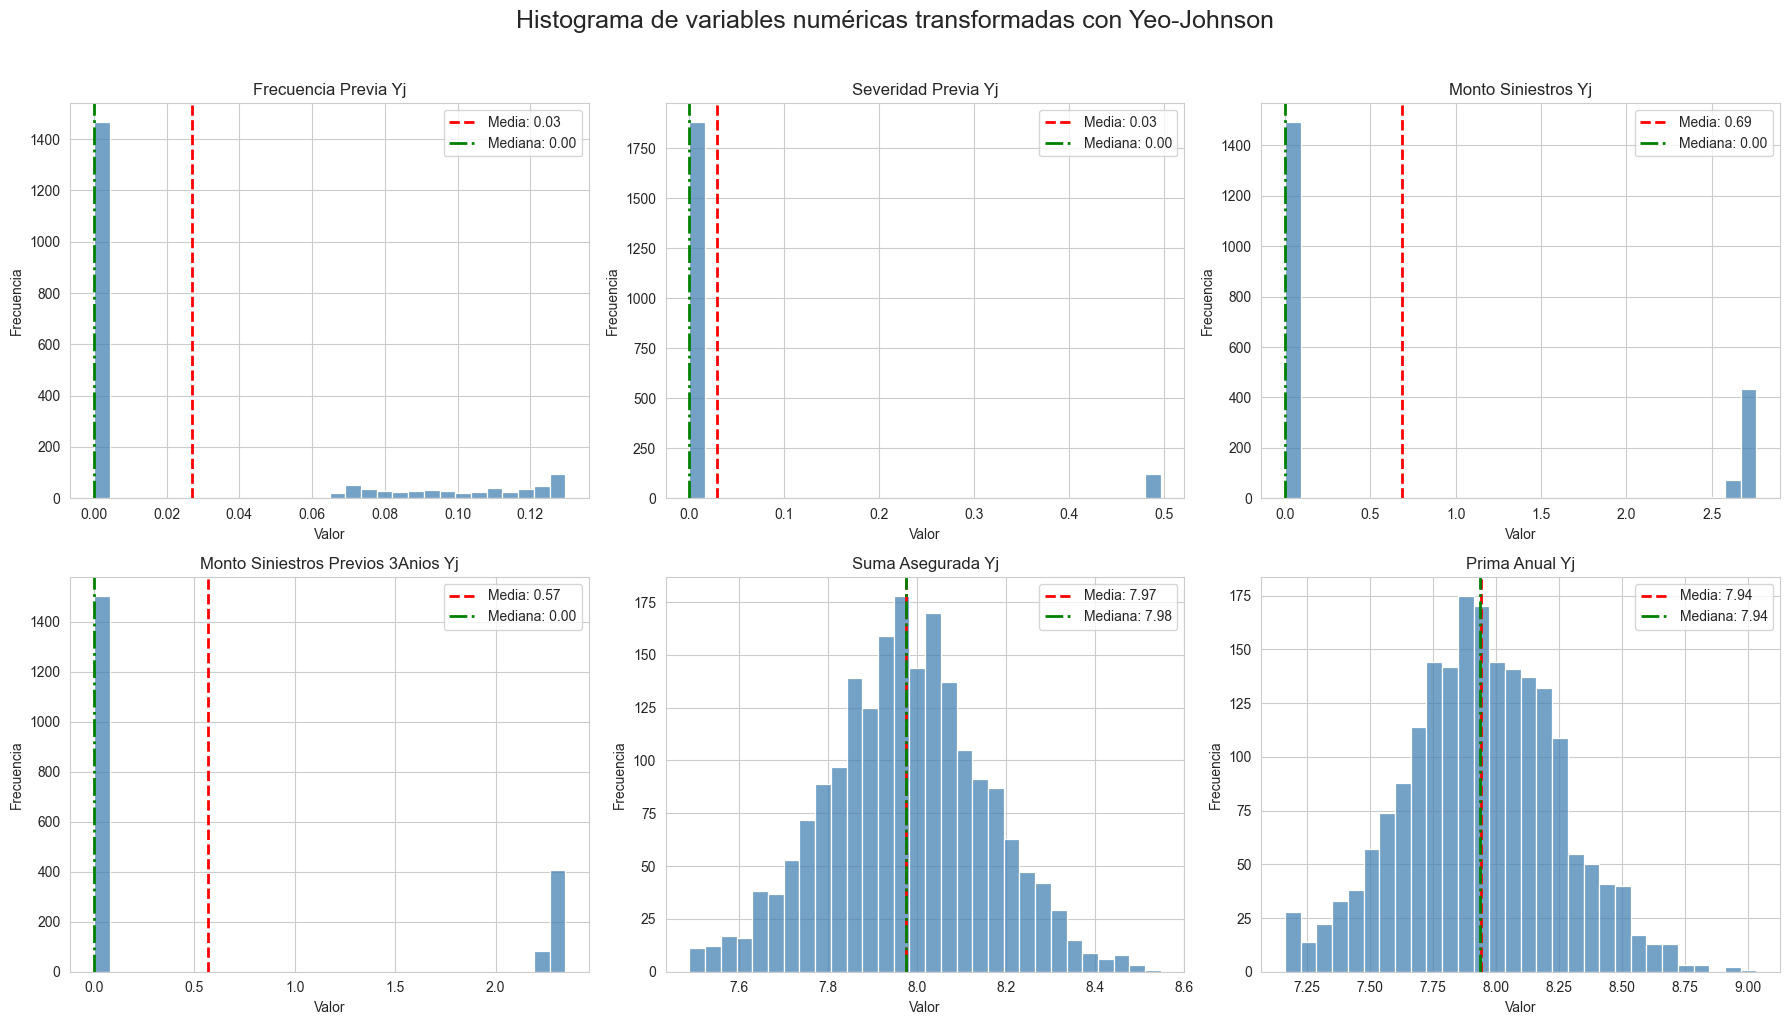

In [8]:
cols = [f'{col}_yj' for col in transform_params.keys()]

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Histograma de variables numéricas transformadas con Yeo-Johnson', fontsize=18, y=1.02)

for ax, col in zip(axes.flat, cols):
    sns.histplot(df[col], bins=30, kde=False, color='steelblue', ax=ax)
    mean_val = df[col].mean()
    median_val = df[col].median()

    ax.axvline(mean_val, color='red', linestyle='--', linewidth=2, label=f'Media: {mean_val:.2f}')
    ax.axvline(median_val, color='green', linestyle='-.', linewidth=2, label=f'Mediana: {median_val:.2f}')
    ax.set_title(col.replace('_', ' ').title())
    ax.set_xlabel('Valor')
    ax.set_ylabel('Frecuencia')
    ax.legend()

plt.tight_layout()
plt.show()

In [ ]:
# PASO 5: Exposición en 2026 + más feature engineering con calendario y segmentación de riesgo
print("🔧 PASO 5: Calculando exposición en 2026 y creando variables de calendarización / riesgo...")

inicio_2026 = pd.Timestamp('2026-01-01')
fin_2026 = pd.Timestamp('2026-12-31')

df['periodo_2026_inicio'] = np.maximum(df['fecha_inicio_vigencia'], inicio_2026)
df['periodo_2026_fin'] = np.minimum(fechas_fin, fin_2026)

df['exposicion_2026_dias'] = (df['periodo_2026_fin'] - df['periodo_2026_inicio']).dt.days.clip(lower=0)
df['exposicion_2026_anios'] = df['exposicion_2026_dias'] / 365.25

duracion_original_dias = (fechas_fin - df['fecha_inicio_vigencia']).dt.days.clip(lower=1)
df['exposicion_2026_ratio'] = df['exposicion_2026_dias'] / duracion_original_dias

# Efectos calendario cíclicos
df['mes_inicio_sin'] = np.sin(2 * np.pi * df['mes_inicio'] / 12)
df['mes_inicio_cos'] = np.cos(2 * np.pi * df['mes_inicio'] / 12)
df['mes_fin_sin'] = np.sin(2 * np.pi * df['mes_fin'] / 12)
df['mes_fin_cos'] = np.cos(2 * np.pi * df['mes_fin'] / 12)

df['trimestre_inicio'] = df['fecha_inicio_vigencia'].dt.quarter
df['bimestre_inicio'] = ((df['mes_inicio'] - 1) // 2 + 1).astype(int)
df['dia_anio_inicio'] = df['fecha_inicio_vigencia'].dt.dayofyear
df['dia_anio_inicio_sin'] = np.sin(2 * np.pi * df['dia_anio_inicio'] / 365)
df['dia_anio_inicio_cos'] = np.cos(2 * np.pi * df['dia_anio_inicio'] / 365)

estaciones = {12: 'Invierno', 1: 'Invierno', 2: 'Invierno',
              3: 'Primavera', 4: 'Primavera', 5: 'Primavera',
              6: 'Verano', 7: 'Verano', 8: 'Verano',
              9: 'Otoño', 10: 'Otoño', 11: 'Otoño'}
df['estacion_inicio'] = df['mes_inicio'].map(estaciones)

# Segmentación de riesgo
df['edad_segmento'] = pd.cut(df['edad_conductor_int'],
                             bins=[0, 25, 64, 120],
                             labels=['Joven', 'Adulto', 'Mayor'])

df['vehiculo_antiguedad_cat'] = pd.cut(df['antiguedad_vehiculo_anios'],
                                       bins=[-1, 3, 9, 100],
                                       labels=['Nuevo', 'Medio', 'Antiguo'])

df['prima_por_suma'] = df['prima_anual'] / df['suma_asegurada']
df['siniestralidad_historica'] = np.where(df['exposicion_anios'] > 0,
                                          df['num_siniestros'] / df['exposicion_anios'],
                                          0)
df['monto_por_dia_exposicion'] = np.where(df['exposicion_dias'] > 0,
                                          df['monto_siniestros'] / df['exposicion_dias'],
                                          0)

df['risk_score'] = (
    df['tiene_siniestro_previo'] * 2
    + df['es_conductor_joven']
    + df['es_uso_comercial']
    + df['vehiculo_antiguo']
    + (df['antiguedad_cliente_anios'] < 1).astype(int)
    + (df['edad_conductor_int'] >= 65).astype(int)
    + (df['prima_por_suma'] > df['prima_por_suma'].median()).astype(int)
)

df['risk_segment'] = pd.cut(df['risk_score'],
                            bins=[-1, 1, 3, 10],
                            labels=['Bajo', 'Medio', 'Alto'])

df['municipio_te_tercil'] = pd.qcut(df['municipio_te'], q=3,
                                    labels=['Bajo', 'Medio', 'Alto'])
df['marca_vehiculo_te_tercil'] = pd.qcut(df['marca_vehiculo_te'], q=3,
                                         labels=['Bajo', 'Medio', 'Alto'])

print("✅ Feature engineering adicional completo.")
print(df[['exposicion_2026_dias', 'exposicion_2026_anios', 'exposicion_2026_ratio',
          'trimestre_inicio', 'estacion_inicio', 'risk_score', 'risk_segment']].head())